# SARSA Behavioural Dataset Demo

This notebook demonstrates how to fit SARSA against the bundled behavioural dataset (`M1.csv`).

State is composite `(location, light, tone)` and action is the animal's location at the next timestep.

In [1]:
from pathlib import Path
import sys

# Add notebooks/ to path so experiment.py can be imported
NOTEBOOKS_DIR = Path.cwd() if (Path.cwd() / 'M1.csv').exists() else Path.cwd() / 'notebooks'
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

DATA_PATH = NOTEBOOKS_DIR / 'M1.csv'
print(f'Data path: {DATA_PATH}  (exists={DATA_PATH.exists()})')

Data path: /Users/zhaoy11/sarsa/notebooks/M1.csv  (exists=True)


In [2]:
import numpy as np
import pandas as pd

from sarsa import sarsa
from experiment import (
    Location,
    StateAxis,
    downsample_behavior_data,
    process_data,
    row_to_state,
    rt_lc_unp_state_spec,
)

rng = np.random.default_rng(0)

In [3]:
MIN_PENALTY  = 1.0   # minimum shock penalty
REWARD_VALUE = 1.0   # value for liquid reward

USER_PARAM_BOUNDS = [
    (MIN_PENALTY, None),  # shock penalty
    (0.0,         None),  # avoidance reward
]

STATE_SPEC  = rt_lc_unp_state_spec   # (3, 4, 4)
ACTION_SIZE = 3                       # P, C, R

In [4]:
def transition_reward_func(user_params, s1, a1, s2):
    """Compute transition reward from next state and user-defined parameters.

    Parameters
    ----------
    user_params : array-like
        [shock_penalty, avoidance_reward]
    s1, a1 : unused (required by API)
    s2 : NDArray
        Next composite state (location, light, tone).

    Returns
    -------
    tuple[NDArray, float]
        (s2, reward)
    """
    shock_value   = user_params[0]
    escape_value  = user_params[1]
    val = 0.0

    if s2[StateAxis.Loc] == Location.R and s2[StateAxis.Light] > 0:
        val += REWARD_VALUE

    if s2[StateAxis.Tone] == 3:
        if s2[StateAxis.Loc] == Location.P:
            val += escape_value   # successful avoidance
        else:
            val -= shock_value    # shock

    return s2, val


def init_params(rng, bounds):
    """Initialise the flat parameter vector within provided bounds."""
    bmin = np.array([b[0] for b in bounds])
    return bmin + 0.5 * rng.random(size=len(bounds))


def make_quintuples(behavior_data):
    """Construct SARSA quintuples from processed behavioural data."""
    quintuples = []
    horizon = len(behavior_data)
    for t in range(horizon - 2):
        t1 = behavior_data.iloc[t]
        t2 = behavior_data.iloc[t + 1]
        t3 = behavior_data.iloc[t + 2]
        s1 = row_to_state(t1)
        s2 = row_to_state(t2)
        s3 = row_to_state(t3)
        a1 = s2[StateAxis.Loc]
        a2 = s3[StateAxis.Loc]
        quintuples.append(sarsa.Quintuple(s1=s1, a1=a1, r2=np.nan, s2=s2, a2=a2))
    return quintuples


def run_session(path, rng):
    """Load data, build quintuples, and fit SARSA."""
    behavior_data = pd.read_csv(path, encoding='unicode_escape', header=0)
    behavior_data = behavior_data.rename(columns={behavior_data.columns[0]: 'Time (s)'})
    behavior_data.columns = map(str.upper, behavior_data.columns)
    behavior_data = downsample_behavior_data(behavior_data, '1s')
    behavior_data = process_data(behavior_data, 'LC')

    quintuples = make_quintuples(behavior_data)
    q0         = np.zeros((*STATE_SPEC, ACTION_SIZE))
    all_bounds = sarsa.PARAM_BOUNDS + USER_PARAM_BOUNDS
    p0         = init_params(rng, all_bounds)

    params, loss, q_trajectory, action_prob = sarsa.fit(
        quintuples,
        q0=q0,
        p0=p0,
        static_params=None,
        transition_reward_func=transition_reward_func,
        user_param_bounds=USER_PARAM_BOUNDS,
        fit_beta=True,   # fit beta explicitly, matching the original demo
    )
    return params, loss, q_trajectory, action_prob

In [5]:
params, loss, q_trajectory, action_prob = run_session(DATA_PATH, rng)
print(f'loss:   {loss:.6f}')
print(f'params: {params}')
print(f'  alpha={params[sarsa.ParamIndex.alpha]:.4f}')
print(f'  beta ={params[sarsa.ParamIndex.beta]:.4f}')
print(f'  gamma={params[sarsa.ParamIndex.gamma]:.4f}')
print(f'  shock penalty  ={params[3]:.4f}')
print(f'  avoidance reward={params[4]:.4f}')

loss:   0.955804
params: [0.3613268  0.6576467  0.99999999 1.         0.45520414]
  alpha=0.3613
  beta =0.6576
  gamma=1.0000
  shock penalty  =1.0000
  avoidance reward=0.4552


/Users/zhaoy11/.cache/uv/archive-v0/CskahTBebvdaA7Mo/lib/python3.13/site-packages/sarsa/sarsa.py:758: UserWarning: Optimized SARSA parameters landed on bounds; interpretation may be weakly identified: gamma≈upper (1)
  warn_if_sarsa_params_hit_bounds(


## Trial-type-averaged action probability

Trials are classified empirically from `LIGHT_ONSET['LC']` and `TONE_ONSET['LC']`:
- **light-only**: light onset with no tone within 90 s
- **tone-only**: tone onset not paired with any light
- **light-then-tone**: tone follows light onset by > 10 s
- **tone-then-light**: light follows tone onset by > 10 s
- **copresented**: light and tone within 10 s of each other

Each trial is aligned to its anchor (light onset for light trials, tone onset for tone-only).

In [7]:
from collections import Counter, defaultdict
from experiment import LIGHT_ONSET, TONE_ONSET

# --- reload behavior data for time axis and observed actions ---
_bd = pd.read_csv(DATA_PATH, encoding='unicode_escape', header=0)
_bd = _bd.rename(columns={_bd.columns[0]: 'Time (s)'})
_bd.columns = map(str.upper, _bd.columns)
_bd = downsample_behavior_data(_bd, '1s')
_bd = process_data(_bd, 'LC')

time_axis = np.array(_bd.index, dtype=float)  # seconds, shape (N,)
T = len(action_prob)

# one-hot observed actions: obs[t, a] = 1 if animal chose action a at step t
# --- classify trials from stimulus timing ---
COPRESENT_THRESH = 10  # seconds
PAIR_WINDOW      = 20  # seconds; 15s-offset tones are paired, 30s-offset are tone-only

light_times = LIGHT_ONSET['LC']
tone_times  = TONE_ONSET['LC']

trials = []
used_tone_idx = set()

for l in light_times:
    dts = tone_times - l
    nearby = np.where(np.abs(dts) <= PAIR_WINDOW)[0]
    if len(nearby) == 0:
        trials.append((l, 'light-only'))
    else:
        j = nearby[np.argmin(np.abs(dts[nearby]))]
        used_tone_idx.add(j)
        dt = dts[j]
        if abs(dt) <= COPRESENT_THRESH:
            trials.append((l, 'copresented'))
        elif dt > 0:
            trials.append((l, 'light-then-tone'))
        else:
            trials.append((l, 'tone-then-light'))

for i, t in enumerate(tone_times):
    if i not in used_tone_idx:
        trials.append((t, 'tone-only'))

print('Trial type counts:', dict(Counter(tp for _, tp in trials)))

Trial type counts: {'light-only': 14, 'tone-then-light': 6, 'light-then-tone': 6, 'copresented': 4, 'tone-only': 4}


### Light-aligned average plot

Model action probability averaged across trials of each type, aligned to the anchor event (light or tone onset).  
Dashed vertical line marks the alignment anchor.

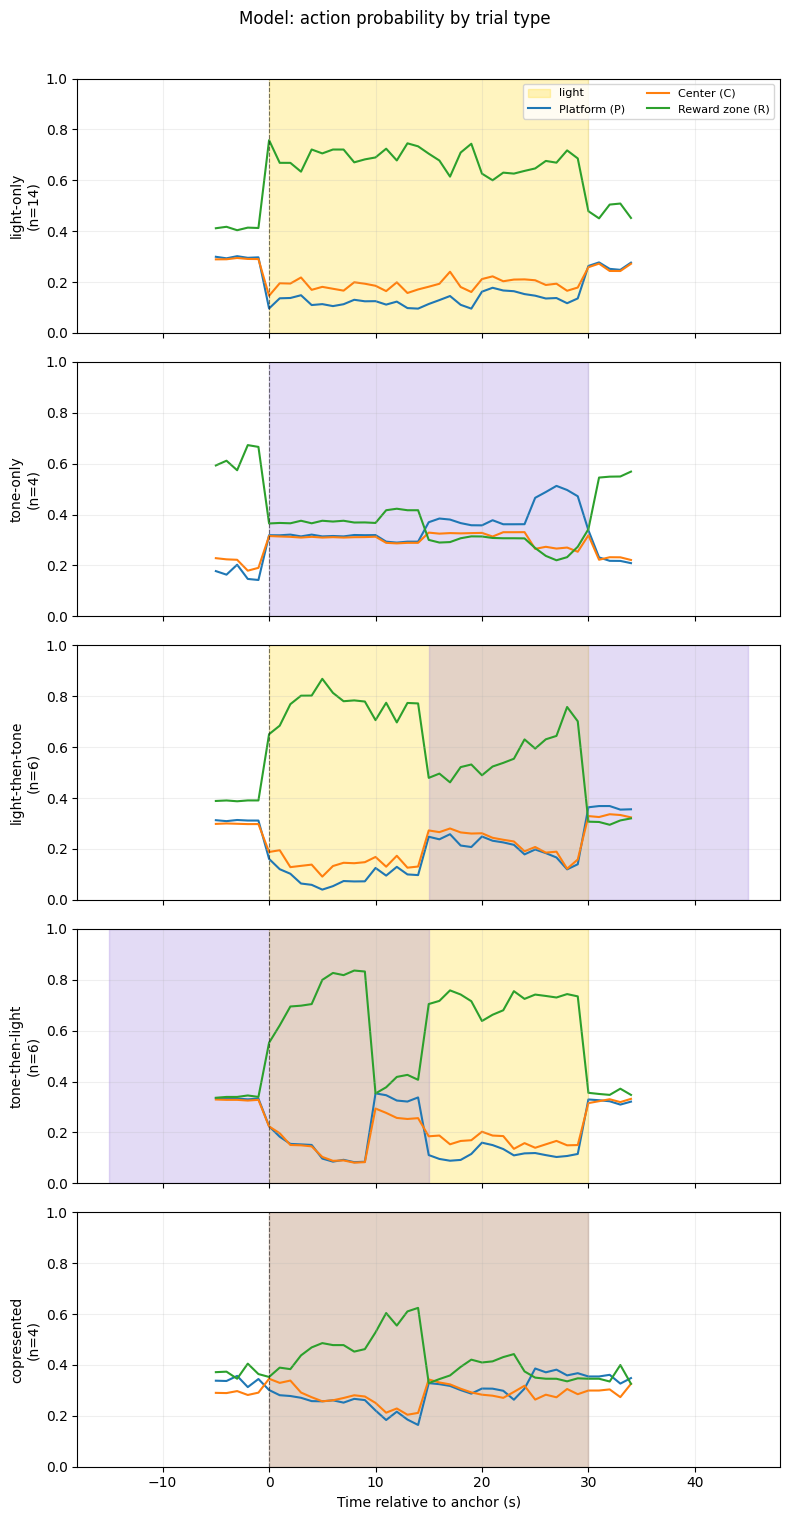

In [8]:
%matplotlib inline

PRE, POST = 5, 35  # seconds before/after anchor
rel_time  = np.arange(-PRE, POST)

TRIAL_TYPES   = ['light-only', 'tone-only', 'light-then-tone', 'tone-then-light', 'copresented']
ACTION_LABELS = ['Platform (P)', 'Center (C)', 'Reward zone (R)']
COLORS        = ['tab:blue', 'tab:orange', 'tab:green']

# Stimulus windows relative to anchor (light onset, or tone onset for tone-only)
# light lasts 30s; tone lasts 30s; offsets from timing analysis (0s, ±15s)
STIM = {
    'light-only':      {'light': (0, 30)},
    'tone-only':       {'tone':  (0, 30)},
    'light-then-tone': {'light': (0, 30), 'tone': (15, 45)},
    'tone-then-light': {'light': (0, 30), 'tone': (-15, 15)},
    'copresented':     {'light': (0, 30), 'tone': (0, 30)},
}

def extract_window(signal, time_axis, anchor, pre, post):
    idx = int(np.argmin(np.abs(time_axis - anchor)))
    s, e = idx - pre, idx + post
    if s < 0 or e > len(signal):
        return None
    return signal[s:e]

ap_by_type = defaultdict(list)
for anchor, ttype in trials:
    w = extract_window(action_prob, time_axis[:T], anchor, PRE, POST)
    if w is not None:
        ap_by_type[ttype].append(w)

valid_types = [t for t in TRIAL_TYPES if t in ap_by_type]
fig, axes = plt.subplots(
    len(valid_types), 1,
    figsize=(8, 3 * len(valid_types)),
    sharey=True, sharex=True,
)

for row, ttype in enumerate(valid_types):
    n       = len(ap_by_type[ttype])
    ap_mean = np.mean(ap_by_type[ttype], axis=0)
    ax      = axes[row]

    # stimulus overlays
    stim = STIM.get(ttype, {})
    if 'light' in stim:
        ax.axvspan(*stim['light'], color='gold',        alpha=0.25, label='light', zorder=0)
    if 'tone' in stim:
        ax.axvspan(*stim['tone'],  color='mediumpurple', alpha=0.25, label='tone',  zorder=0)

    # action probability traces
    for i, (label, color) in enumerate(zip(ACTION_LABELS, COLORS)):
        ax.plot(rel_time, ap_mean[:, i], color=color, label=label, zorder=1)

    ax.axvline(0, color='k', linestyle='--', lw=0.8, alpha=0.5, zorder=2)
    ax.set_ylim(0, 1)
    ax.set_ylabel(f'{ttype}\n(n={n})')
    ax.grid(True, alpha=0.2)
    if row == 0:
        ax.legend(fontsize=8, ncol=2)

axes[-1].set_xlabel('Time relative to anchor (s)')
fig.suptitle('Model: action probability by trial type', y=1.01)
fig.tight_layout()
plt.show()
